In [72]:
import pandas as pd
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.metrics import make_scorer, recall_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn import metrics
from sklearn import tree
from sklearn import metrics
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import joblib

In [73]:
subset_a = pd.read_csv('/content/drive/MyDrive/L5 Sem2 ML/CW/loan_classification_data.csv')

In [74]:
X = subset_a.drop(columns=['loan_approval_status'])
y = subset_a['loan_approval_status']

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [76]:
rejected_recall = make_scorer(recall_score, pos_label=1)

In [77]:
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

nb_params = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

In [78]:
lr_base = GridSearchCV(
    LogisticRegression(random_state=42, class_weight='balanced'),
    lr_params,
    cv=5,
    scoring=rejected_recall,
    n_jobs=-1
)

nb_base = GridSearchCV(GaussianNB(), nb_params, cv=5, scoring=rejected_recall, n_jobs=-1)

In [79]:
ensemble = VotingClassifier(
    estimators=[
        ('lr', lr_base),
        ('nb', nb_base)
    ],
    voting='soft'
)

In [80]:
ensemble.fit(X_train, y_train)

VotingClassifier(estimators=[('lr',
                              GridSearchCV(cv=5,
                                           estimator=LogisticRegression(class_weight='balanced',
                                                                        random_state=42),
                                           n_jobs=-1,
                                           param_grid={'C': [0.01, 0.1, 1, 10,
                                                             100],
                                                       'solver': ['lbfgs',
                                                                  'liblinear']},
                                           scoring=make_scorer(recall_score, response_method='predict', pos_label=1))),
                             ('nb',
                              GridSearchCV(cv=5, estimator=GaussianNB(),
                                           n_jobs=-1,
                                           param_grid={'var_smoothing': [1e-09,
                                                                         1e-08,
                                                                         1e-07,
                                                                         1e-06,
                                                                         1e-05]},
                                           scoring=make_scorer(recall_score, response_method='predict', pos_label=1)))],
                 voting='soft')

In [81]:
ensemble_predictions = ensemble.predict(X_test)

In [82]:
print("="*60)
print("Ensemble Classifier Evaluation")
print("="*60)

cm = confusion_matrix(y_test, ensemble_predictions)
cm_df = pd.DataFrame(
    cm,
    index=['Actual Rejected', 'Actual Approved'],
    columns=['Predicted Rejected', 'Predicted Approved']
)

fig_cm = px.imshow(
    cm_df,
    text_auto=True,
    color_continuous_scale='Greens',
    title='Confusion Matrix - Ensemble Classifier'
)
fig_cm.show()

Ensemble Classifier Evaluation


Confusion Matrix

In [83]:
print("\nClassification Report - Ensemble Classifier")
print(classification_report(y_test, ensemble_predictions, target_names=['Rejected', 'Approved']))


Classification Report - Ensemble Classifier
              precision    recall  f1-score   support

    Rejected       0.95      0.82      0.88     10059
    Approved       0.42      0.77      0.54      1670

    accuracy                           0.81     11729
   macro avg       0.69      0.79      0.71     11729
weighted avg       0.88      0.81      0.83     11729



Classification Report

In [84]:
y_prob = ensemble.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(
    x=fpr, y=tpr,
    mode='lines',
    name=f'Ensemble ROC Curve (AUC = {roc_auc:.2f})'
))
fig_roc.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    line=dict(dash='dash', color='gray'),
    name='Random Classifier'
))
fig_roc.update_layout(
    title='AUC-ROC Curve - Ensemble Classifier',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate'
)
fig_roc.show()

print(f"AUC Score: {roc_auc:.2f}")

AUC Score: 0.88


AUC-ROC Curve

In [85]:
subset_b = pd.read_csv('/content/drive/MyDrive/L5 Sem2 ML/CW/loan_regression_data.csv')

In [86]:
print("Subset B shape:", subset_b.shape)
print("Subset B columns:", subset_b.columns.tolist())
subset_b.head()

Subset B shape: (50295, 20)
Subset B columns: ['age', 'income', 'employment_length', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'credit_history_length', 'home_ownership_MORTGAGE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'payment_default_on_file_N', 'payment_default_on_file_Y', 'max_allowed_loan']


,age,income,employment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,home_ownership_MORTGAGE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,payment_default_on_file_N,payment_default_on_file_Y,max_allowed_loan
0,-1.087927,-1.479895,-1.204656,1.039305,-1.214711,-0.427932,-0.450108,-0.856727,-0.038986,4.205788,-1.044345,-0.429488,1.944005,-0.346305,-0.478719,-0.453837,-0.4537,0.417363,-0.417363,69307.59174
1,-1.087927,-1.445688,-0.691706,2.836651,2.006927,0.335502,-0.698298,-0.856727,-0.038986,4.205788,-1.044345,-0.429488,1.944005,-0.346305,-0.478719,-0.453837,-0.4537,-2.395998,2.395998,69307.59174
2,-0.755699,-1.548309,0.077718,3.735324,0.573990,1.644245,-0.698298,-0.856727,-0.038986,-0.237768,0.957538,-0.429488,-0.514402,-0.346305,2.088910,-0.453837,-0.4537,0.417363,-0.417363,69307.59174
3,2.068236,3.366182,-0.435231,4.633996,-0.882006,0.335502,1.287227,-0.856727,-0.038986,-0.237768,0.957538,-0.429488,1.944005,-0.346305,-0.478719,-0.453837,-0.4537,0.417363,-0.417363,35000.00000
4,2.068236,0.743547,-0.435231,4.633996,0.573990,2.516741,2.031798,1.167232,-0.038986,-0.237768,-1.044345,-0.429488,-0.514402,2.887625,-0.478719,-0.453837,-0.4537,0.417363,-0.417363,35000.00000


In [87]:
X = subset_b.drop(columns=['max_allowed_loan'])
y = subset_b['max_allowed_loan']

In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [89]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (40236, 19)
X_test shape: (10059, 19)


In [90]:
dt1 = DecisionTreeRegressor(random_state=42)
dt1.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

DT-1: Fully grown tree with no depth limit

In [91]:
dt2 = DecisionTreeRegressor(max_depth=4, random_state=42)
dt2.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

DT-2: Pruned tree limited to 4 levels

In [92]:
dt1_predictions = dt1.predict(X_test)
dt2_predictions = dt2.predict(X_test)

print("DT-1 tree depth:", dt1.get_depth())
print("DT-2 tree depth:", dt2.get_depth())

DT-1 tree depth: 25
DT-2 tree depth: 4


In [93]:
dt1_mae = mean_absolute_error(y_test, dt1_predictions)
dt1_mse = mean_squared_error(y_test, dt1_predictions)
dt1_r2 = r2_score(y_test, dt1_predictions)

In [94]:
dt2_mae = mean_absolute_error(y_test, dt2_predictions)
dt2_mse = mean_squared_error(y_test, dt2_predictions)
dt2_r2 = r2_score(y_test, dt2_predictions)

In [95]:
results = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'R²'],
    'DT-1 (Fully Grown)': [dt1_mae, dt1_mse, dt1_r2],
    'DT-2 (Pruned)': [dt2_mae, dt2_mse, dt2_r2]
})

print(results.to_string(index=False))

Metric  DT-1 (Fully Grown)  DT-2 (Pruned)
   MAE        1.300550e+03   1.031547e+04
   MSE        1.352278e+08   3.973897e+08
    R²        9.450400e-01   8.384908e-01


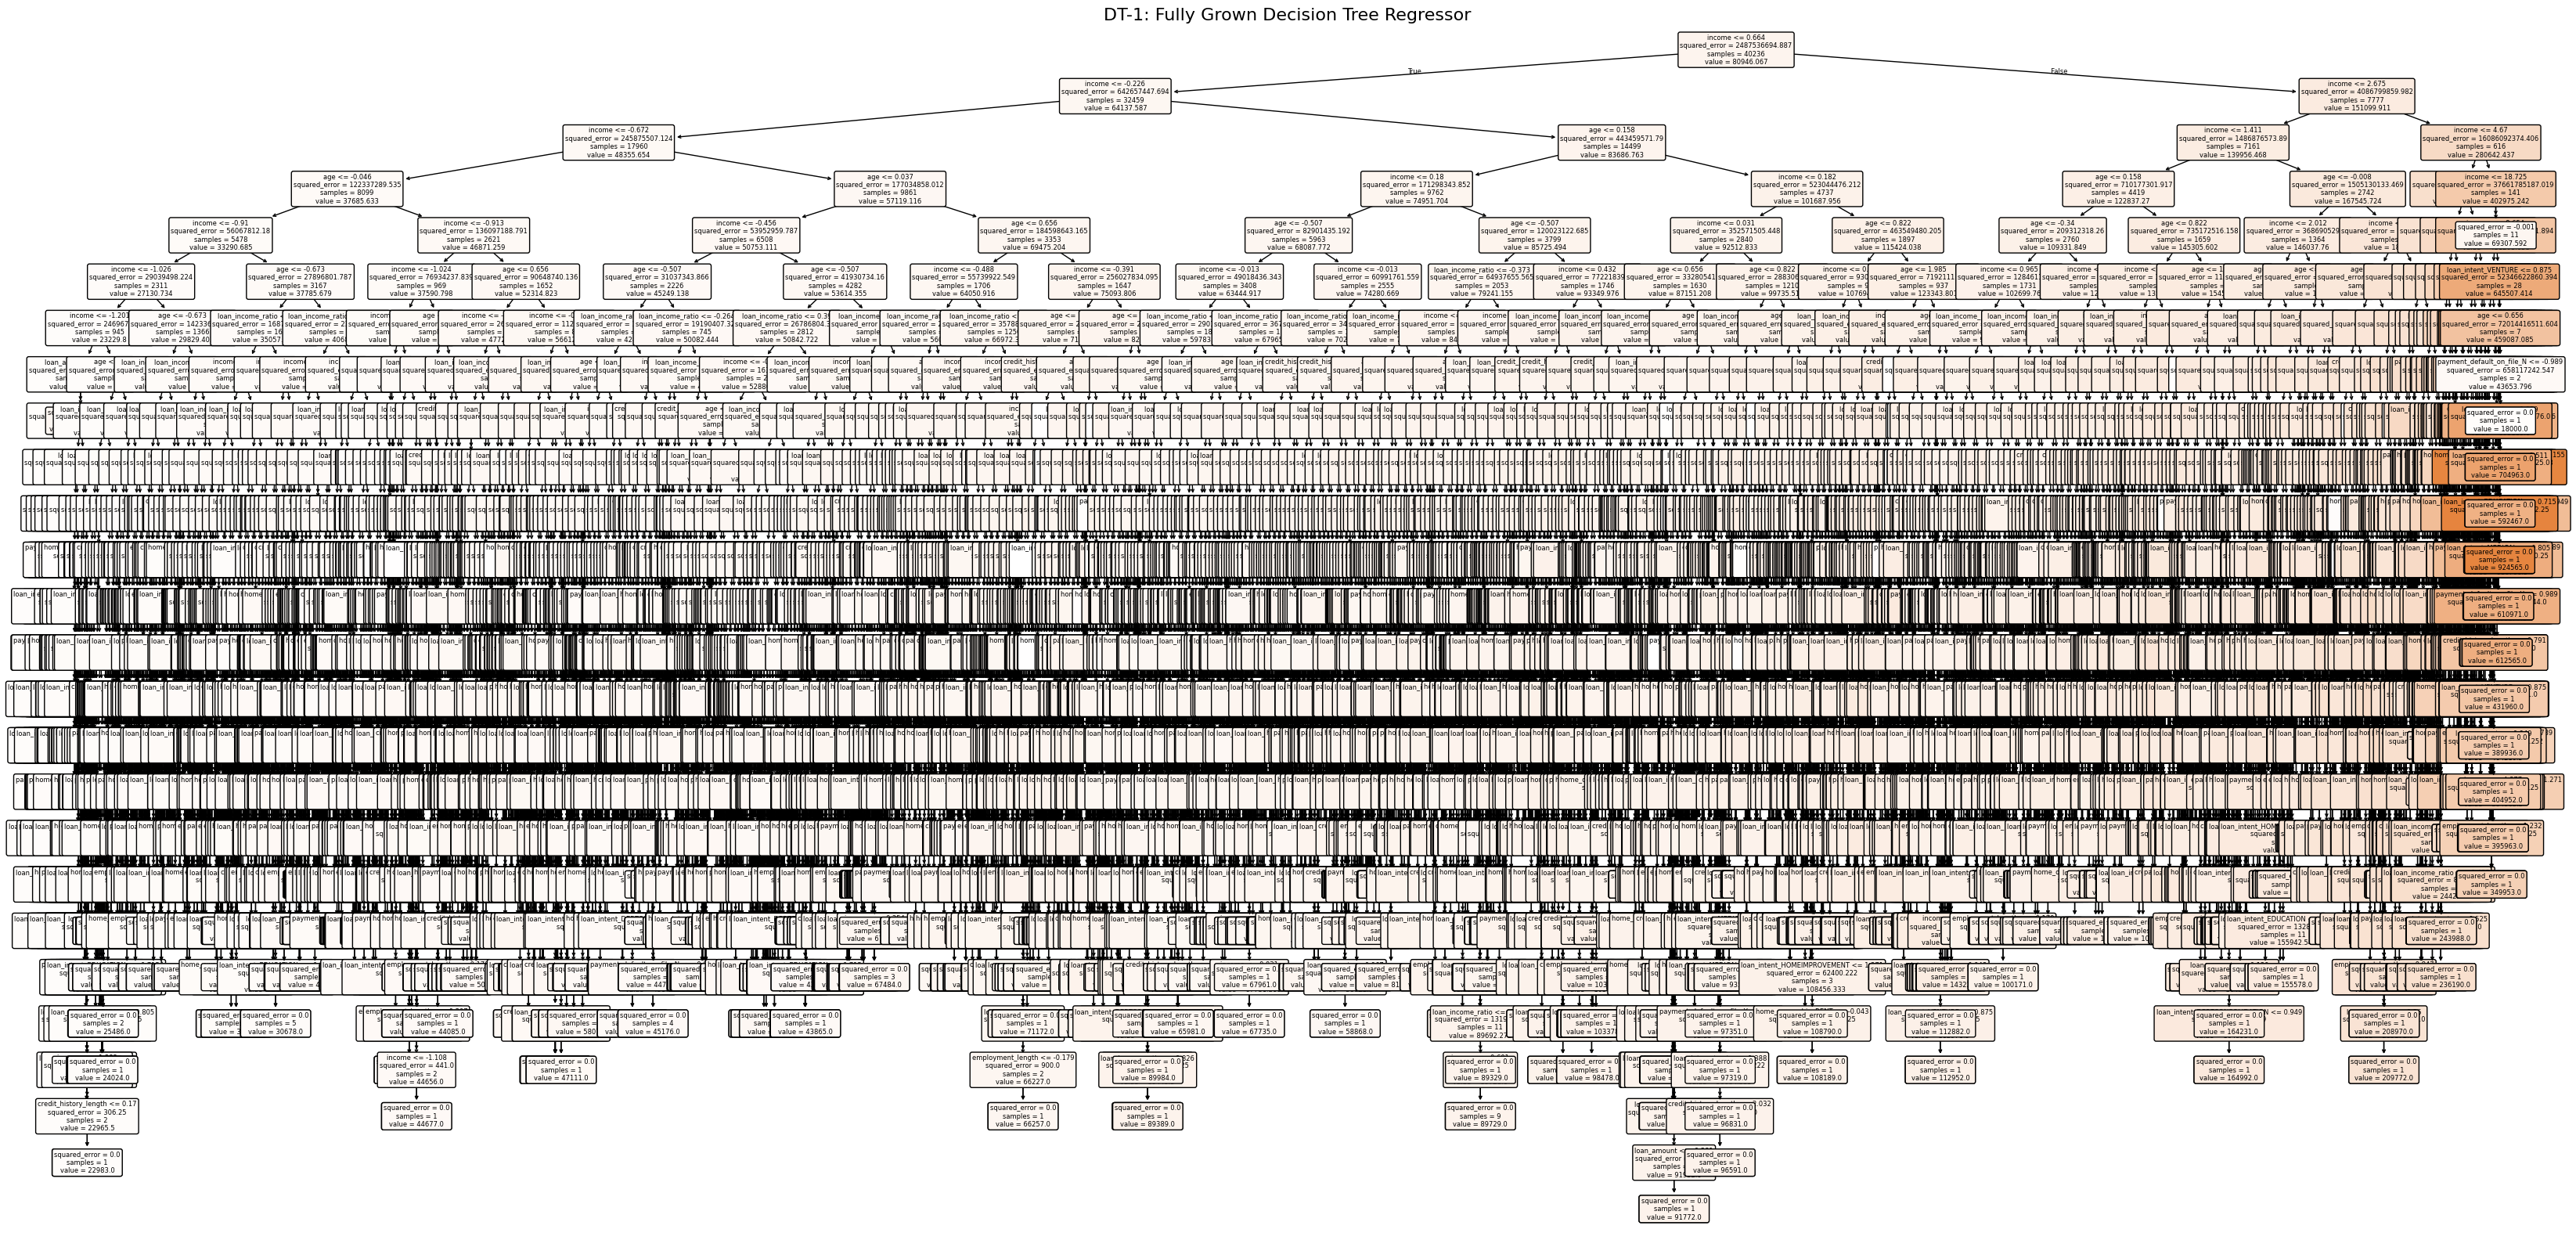

In [96]:
plt.figure(figsize=(40, 20))
plot_tree(
    dt1,
    feature_names=X.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=6
)
plt.title('DT-1: Fully Grown Decision Tree Regressor', fontsize=16)
plt.savefig('dt1_fully_grown.png', dpi=300, bbox_inches='tight')
plt.show()

Visualise DT-1 (Fully Grown)

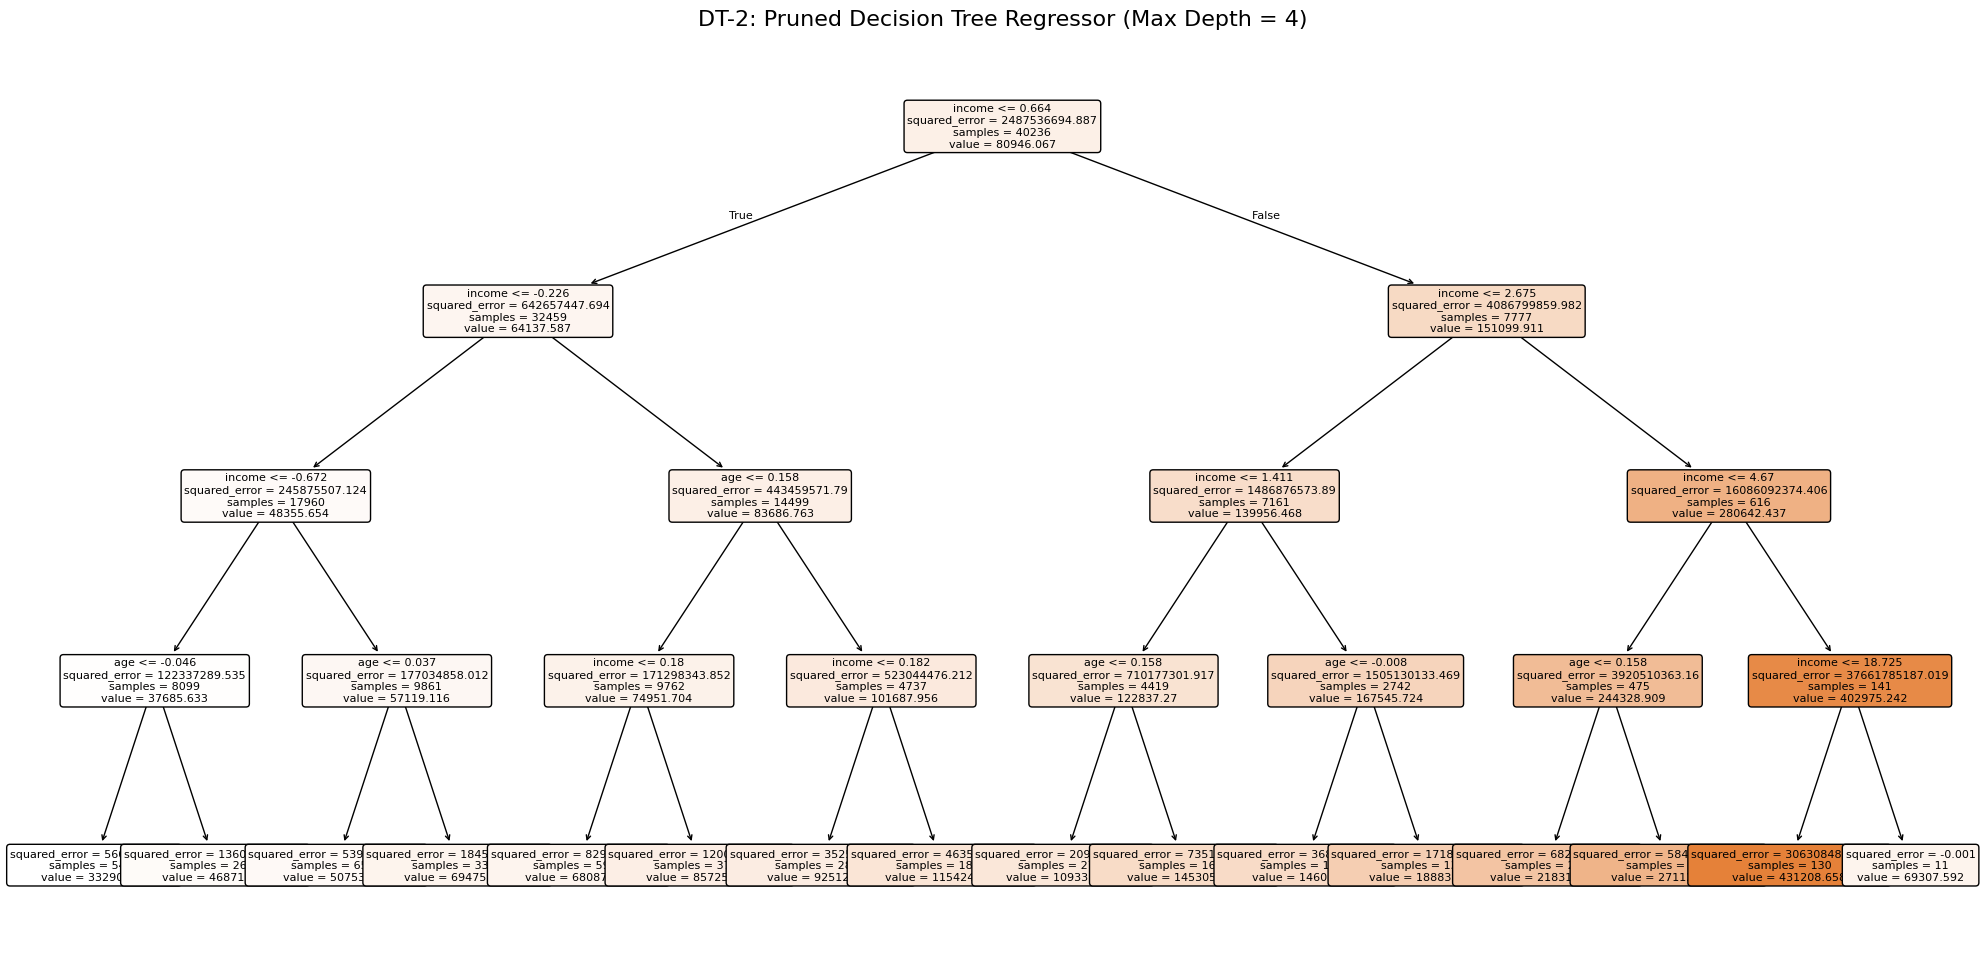

In [97]:
plt.figure(figsize=(25, 12))
plot_tree(
    dt2,
    feature_names=X.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('DT-2: Pruned Decision Tree Regressor (Max Depth = 4)', fontsize=16)
plt.savefig('dt2_pruned.png', dpi=300, bbox_inches='tight')
plt.show()

Visualise DT-2 (Pruned)

In [98]:
subset_b.head()

,age,income,employment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,home_ownership_MORTGAGE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,payment_default_on_file_N,payment_default_on_file_Y,max_allowed_loan
0,-1.087927,-1.479895,-1.204656,1.039305,-1.214711,-0.427932,-0.450108,-0.856727,-0.038986,4.205788,-1.044345,-0.429488,1.944005,-0.346305,-0.478719,-0.453837,-0.4537,0.417363,-0.417363,69307.59174
1,-1.087927,-1.445688,-0.691706,2.836651,2.006927,0.335502,-0.698298,-0.856727,-0.038986,4.205788,-1.044345,-0.429488,1.944005,-0.346305,-0.478719,-0.453837,-0.4537,-2.395998,2.395998,69307.59174
2,-0.755699,-1.548309,0.077718,3.735324,0.573990,1.644245,-0.698298,-0.856727,-0.038986,-0.237768,0.957538,-0.429488,-0.514402,-0.346305,2.088910,-0.453837,-0.4537,0.417363,-0.417363,69307.59174
3,2.068236,3.366182,-0.435231,4.633996,-0.882006,0.335502,1.287227,-0.856727,-0.038986,-0.237768,0.957538,-0.429488,1.944005,-0.346305,-0.478719,-0.453837,-0.4537,0.417363,-0.417363,35000.00000
4,2.068236,0.743547,-0.435231,4.633996,0.573990,2.516741,2.031798,1.167232,-0.038986,-0.237768,-1.044345,-0.429488,-0.514402,2.887625,-0.478719,-0.453837,-0.4537,0.417363,-0.417363,35000.00000


In [102]:
scaler = joblib.load('/content/drive/MyDrive/L5 Sem2 ML/CW' + 'loan_scaler.joblib')
model_features = joblib.load('/content/drive/MyDrive/L5 Sem2 ML/CW' + 'feature_columns.joblib')

In [103]:
client_60256 = pd.DataFrame([{
    'age': 56,
    'income': 57000,
    'home_ownership': 'RENT',
    'employment_length': 15.0,
    'loan_intent': 'MEDICAL',
    'loan_amount': 25700,
    'loan_interest_rate': 23.0,
    'loan_income_ratio': 0.10,
    'payment_default_on_file': 'N',
    'credit_history_length': 35
}])

In [104]:
client_encoded = pd.get_dummies(client_60256)

client_aligned = client_encoded.reindex(columns=model_features, fill_value=0)

In [105]:
client_scaled_array = scaler.transform(client_aligned)

client_scaled = pd.DataFrame(client_scaled_array, columns=model_features)

print(client_scaled)

        age   income  employment_length  loan_amount  loan_interest_rate  \
0  4.726058 -0.19714           2.642467     2.962465            4.059156   

   loan_income_ratio  credit_history_length  home_ownership_MORTGAGE  \
0          -0.646056                 7.2438                -0.856727   

   home_ownership_OTHER  home_ownership_OWN  home_ownership_RENT  \
0             -0.038986           -0.237768             0.957538   

   loan_intent_DEBTCONSOLIDATION  loan_intent_EDUCATION  \
0                      -0.429488              -0.514402   

   loan_intent_HOMEIMPROVEMENT  loan_intent_MEDICAL  loan_intent_PERSONAL  \
0                    -0.346305              2.08891             -0.453837   

   loan_intent_VENTURE  payment_default_on_file_N  payment_default_on_file_Y  
0              -0.4537                   0.417363                  -0.417363  


In [106]:
prediction = dt1.predict(client_scaled)
print(f"The Predicted Maximum Loan Amount for Client 60256 is: {prediction[0]:.2f}")

The Predicted Maximum Loan Amount for Client 60256 is: 87430.00


In [107]:
best_tree = dt1

In [109]:
decision_path = best_tree.decision_path(client_scaled)
node_indicator = decision_path.toarray()[0]
node_ids = np.where(node_indicator)[0]

In [110]:
feature_names = X.columns.tolist()
threshold = best_tree.tree_.threshold
feature = best_tree.tree_.feature

In [111]:
print("Decision path for Client 60256:")
print("="*50)

for node_id in node_ids[:-1]:
    feature_name = feature_names[feature[node_id]]
    threshold_value = threshold[node_id]
    client_value = client_60256[feature_name].values[0]

    if client_value <= threshold_value:
        direction = "<="
    else:
        direction = ">"

    print(f"Node {node_id}: {feature_name} {direction} {threshold_value:.4f} "
          f"(Client value: {client_value:.4f})")

print("="*50)
print(f"Final predicted value: £{prediction[0]:,.2f}")

Decision path for Client 60256:
Node 0: income > 0.6638 (Client value: 57000.0000)
Node 1: income > -0.2256 (Client value: 57000.0000)
Node 20293: age > 0.1579 (Client value: 56.0000)
Node 29301: income > 0.1821 (Client value: 57000.0000)
Node 29302: income > 0.0309 (Client value: 57000.0000)
Node 29303: age > 0.6563 (Client value: 56.0000)
Node 29949: age > 1.9852 (Client value: 56.0000)
Node 30823: age > 2.1513 (Client value: 56.0000)
Node 30871: loan_income_ratio <= 0.4991 (Client value: 0.1000)
Node 30872: age > 3.8124 (Client value: 56.0000)
Node 31106: age > 5.4736 (Client value: 56.0000)
Node 31107: age > 4.8091 (Client value: 56.0000)
Node 31108: loan_amount > 0.0508 (Client value: 25700.0000)
Node 31132: employment_length > -0.6917 (Client value: 15.0000)
Node 31136: loan_income_ratio <= 0.3900 (Client value: 0.1000)
Node 31137: loan_interest_rate > 1.5968 (Client value: 23.0000)
Final predicted value: £87,430.00


In [112]:
predictions = dt2.predict(X_test)

mae = metrics.mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error (MAE): {mae}")

r2 = metrics.r2_score(y_test, predictions)
print(f"R-Squared (R2): {r2}")

Mean Absolute Error (MAE): 10315.469970940265
R-Squared (R2): 0.8384907537044434


In [113]:
dt1_predictions = dt1.predict(X_test)

dt1_mae = metrics.mean_absolute_error(y_test, dt1_predictions)
print(f"DT-1 Mean Absolute Error (MAE): {dt1_mae:.2f}")

dt1_r2 = metrics.r2_score(y_test, dt1_predictions)
print(f"DT-1 R-Squared (R2): {dt1_r2:.4f}")

DT-1 Mean Absolute Error (MAE): 1300.55
DT-1 R-Squared (R2): 0.9450
